In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import RobustScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [2]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(loss='huber', alpha=0.95, random_state=42)),
    ('svr', SVR(kernel='rbf', C=10, epsilon=0.1))
]

In [5]:
rf_pred = base_models[0][1].fit(X_train, y_train).predict(X_test)
gb_pred = base_models[1][1].fit(X_train, y_train).predict(X_test)
svr_pred = base_models[2][1].fit(X_train, y_train).predict(X_test)
final_pred = (0.5 * gb_pred) + (0.3 * rf_pred) + (0.2 * svr_pred)
print(f"Weighted MAE: {mean_absolute_error(y_test, final_pred):.4f}")


Weighted MAE: 220.4684


In [6]:
# Option 2: Stacking Ensemble (More Advanced)
stacking_regressor = StackingRegressor(
    estimators=base_models,
    final_estimator=RandomForestRegressor(n_estimators=50, random_state=42)
)


In [7]:
stacking_pipeline = Pipeline([
    ('model', TransformedTargetRegressor(
        regressor=stacking_regressor,
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

In [8]:
stacking_pipeline.fit(X_train, y_train)
stack_pred = stacking_pipeline.predict(X_test)
print(f"Stacking MAE: {mean_absolute_error(y_test, stack_pred):.4f}")

Stacking MAE: 118.1687


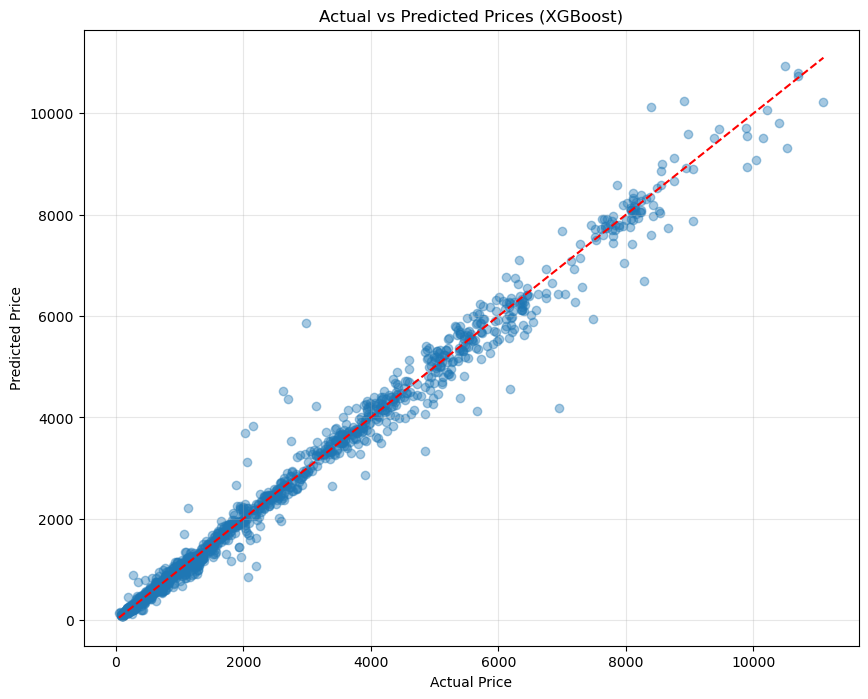

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(y_test, stack_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (XGBoost)")
plt.grid(alpha=0.3)
plt.savefig("xgboost_actual_vs_predicted.png", dpi=300)
plt.show()

In [10]:
import joblib

joblib.dump(stacking_pipeline, "../../../models/ensemble/stack_model_label_v3.joblib")

['../../../models/ensemble/stack_model_label_v3.joblib']